# Proyek Data Mining: Klasifikasi Tingkat Risiko Penyakit Jantung
Notebook ini digunakan untuk menganalisis data rekam medis pasien dan melakukan klasifikasi risiko penyakit jantung menggunakan dua algoritma: **Decision Tree C4.5** dan **K-Nearest Neighbor (KNN)**.

## Langkah 1: Memuat Library Dasar untuk Eksplorasi Data (EDA)
Pada tahap awal ini, kita mengimpor beberapa pustaka utama seperti `pandas` untuk memproses tabel data, `numpy` untuk operasi matriks/angka, serta `matplotlib` untuk kebutuhan visualisasi grafik dasar.

In [52]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # Pustaka untuk plotting grafik
import numpy as np # Aljabar linear dan pemrosesan angka
import os # Mengakses struktur direktori file
import pandas as pd # Pemrosesan data tabel / DataFrame

print("Library dasar untuk EDA berhasil dimuat!")

Library dasar untuk EDA berhasil dimuat!


## Langkah 2: Membuat Fungsi Visualisasi Distribusi Kolom
Finsi ini dirancang untuk membuat grafik batang atau histogram secara otomatis untuk setiap fitur/kolom medis di dalam dataset. Fungsi ini membantu kita melihat sebaran data pasien secara visual.
*(Catatan: Kode pembagian pembentuk baris grafik telah diperbaiki menggunakan `//` agar menghasilkan angka bulat/integer).*

In [53]:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)

    # Menggunakan '//' agar hasil pembagian berupa integer (angka bulat)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow

    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(int(nGraphRow), int(nGraphPerRow), i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

## Langkah 3: Membuat Fungsi Visualisasi Matriks Korelasi
Fungsi ini digunakan untuk mengukur seberapa kuat hubungan antar-parameter medis (misalnya hubungan antara usia dengan kadar kolesterol).
*(Catatan: Parameter `axis='columns'` dan `numeric_only=True` ditambahkan agar kompatibel dengan Pandas versi terbaru).*

In [54]:
# GANTI ISI CELL 6 DENGAN KODE MODERN INI:
import seaborn as sns

def plotCorrelationMatrix(df, graphWidth):
    filename = getattr(df, 'dataframeName', 'Dataset')

    # Membersihkan data dari kolom kosong
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]

    # Menghitung matriks korelasi khusus angka
    corr = df.corr(numeric_only=True)

    # Membuat canvas grafik baru tanpa fignum manual (Aman dari Bug!)
    plt.figure(figsize=(graphWidth, graphWidth), dpi=100)

    # Membuat Heatmap yang cantik dengan warna Coolwarm dan menampilkan angka (annot=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})

    plt.title(f'Correlation Matrix for {filename}', fontsize=14, pad=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Langkah 4: Membuat Fungsi Scatter dan Density Plot
Fungsi ini memetakan sebaran titik data rekam medis pasien dalam bentuk diagram sebar (*scatter plot*) untuk melihat pola pengelompokan awal data secara visual.

In [55]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number])
    df = df.dropna(axis='columns') # Perbaikan parameter dropna bawaan pandas
    df = df[[col for col in df if df[col].nunique() > 1]]
    columnNames = list(df)
    if len(columnNames) > 10:
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr: %.2f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

## Langkah 5: Membaca dan Memuat Dataset Rekam Medis (`heart.csv`)
Di sini kita akan membaca file dataset rekam medis jantung.
*(Catatan: Jika dijalankan di Google Colab/Lokal setelah mengunggah file, pastikan path filenya diubah langsung ke `'heart.csv'`).*

In [56]:
# Jalankan ini di cell pembacaan data (Langkah 5)
df1 = pd.read_csv('heart.csv', delimiter=',')
df1 = df1.drop_duplicates() # Menghapus duplikasi baris agar kembali ke 303 sampel asli UCI
df1.dataframeName = 'heart.csv'
nRow, nCol = df1.shape
print(f'Berhasil memuat data unik sesuai paper! Terdapat {nRow} baris dan {nCol} kolom.')

Berhasil memuat data unik sesuai paper! Terdapat 302 baris dan 14 kolom.


## Langkah 6: Menampilkan Pratinjau 5 Data Pertama
Kita menampilkan 5 baris teratas dari dataset untuk memeriksa nama-nama kolom rekam medis dan tipe data awal yang disajikan.

In [57]:
df1.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Langkah 7: Eksekusi Grafik Distribusi Kolom
Menjalankan fungsi visualisasi untuk melihat bentuk sebaran frekuensi data pada masing-masing parameter rekam medis.

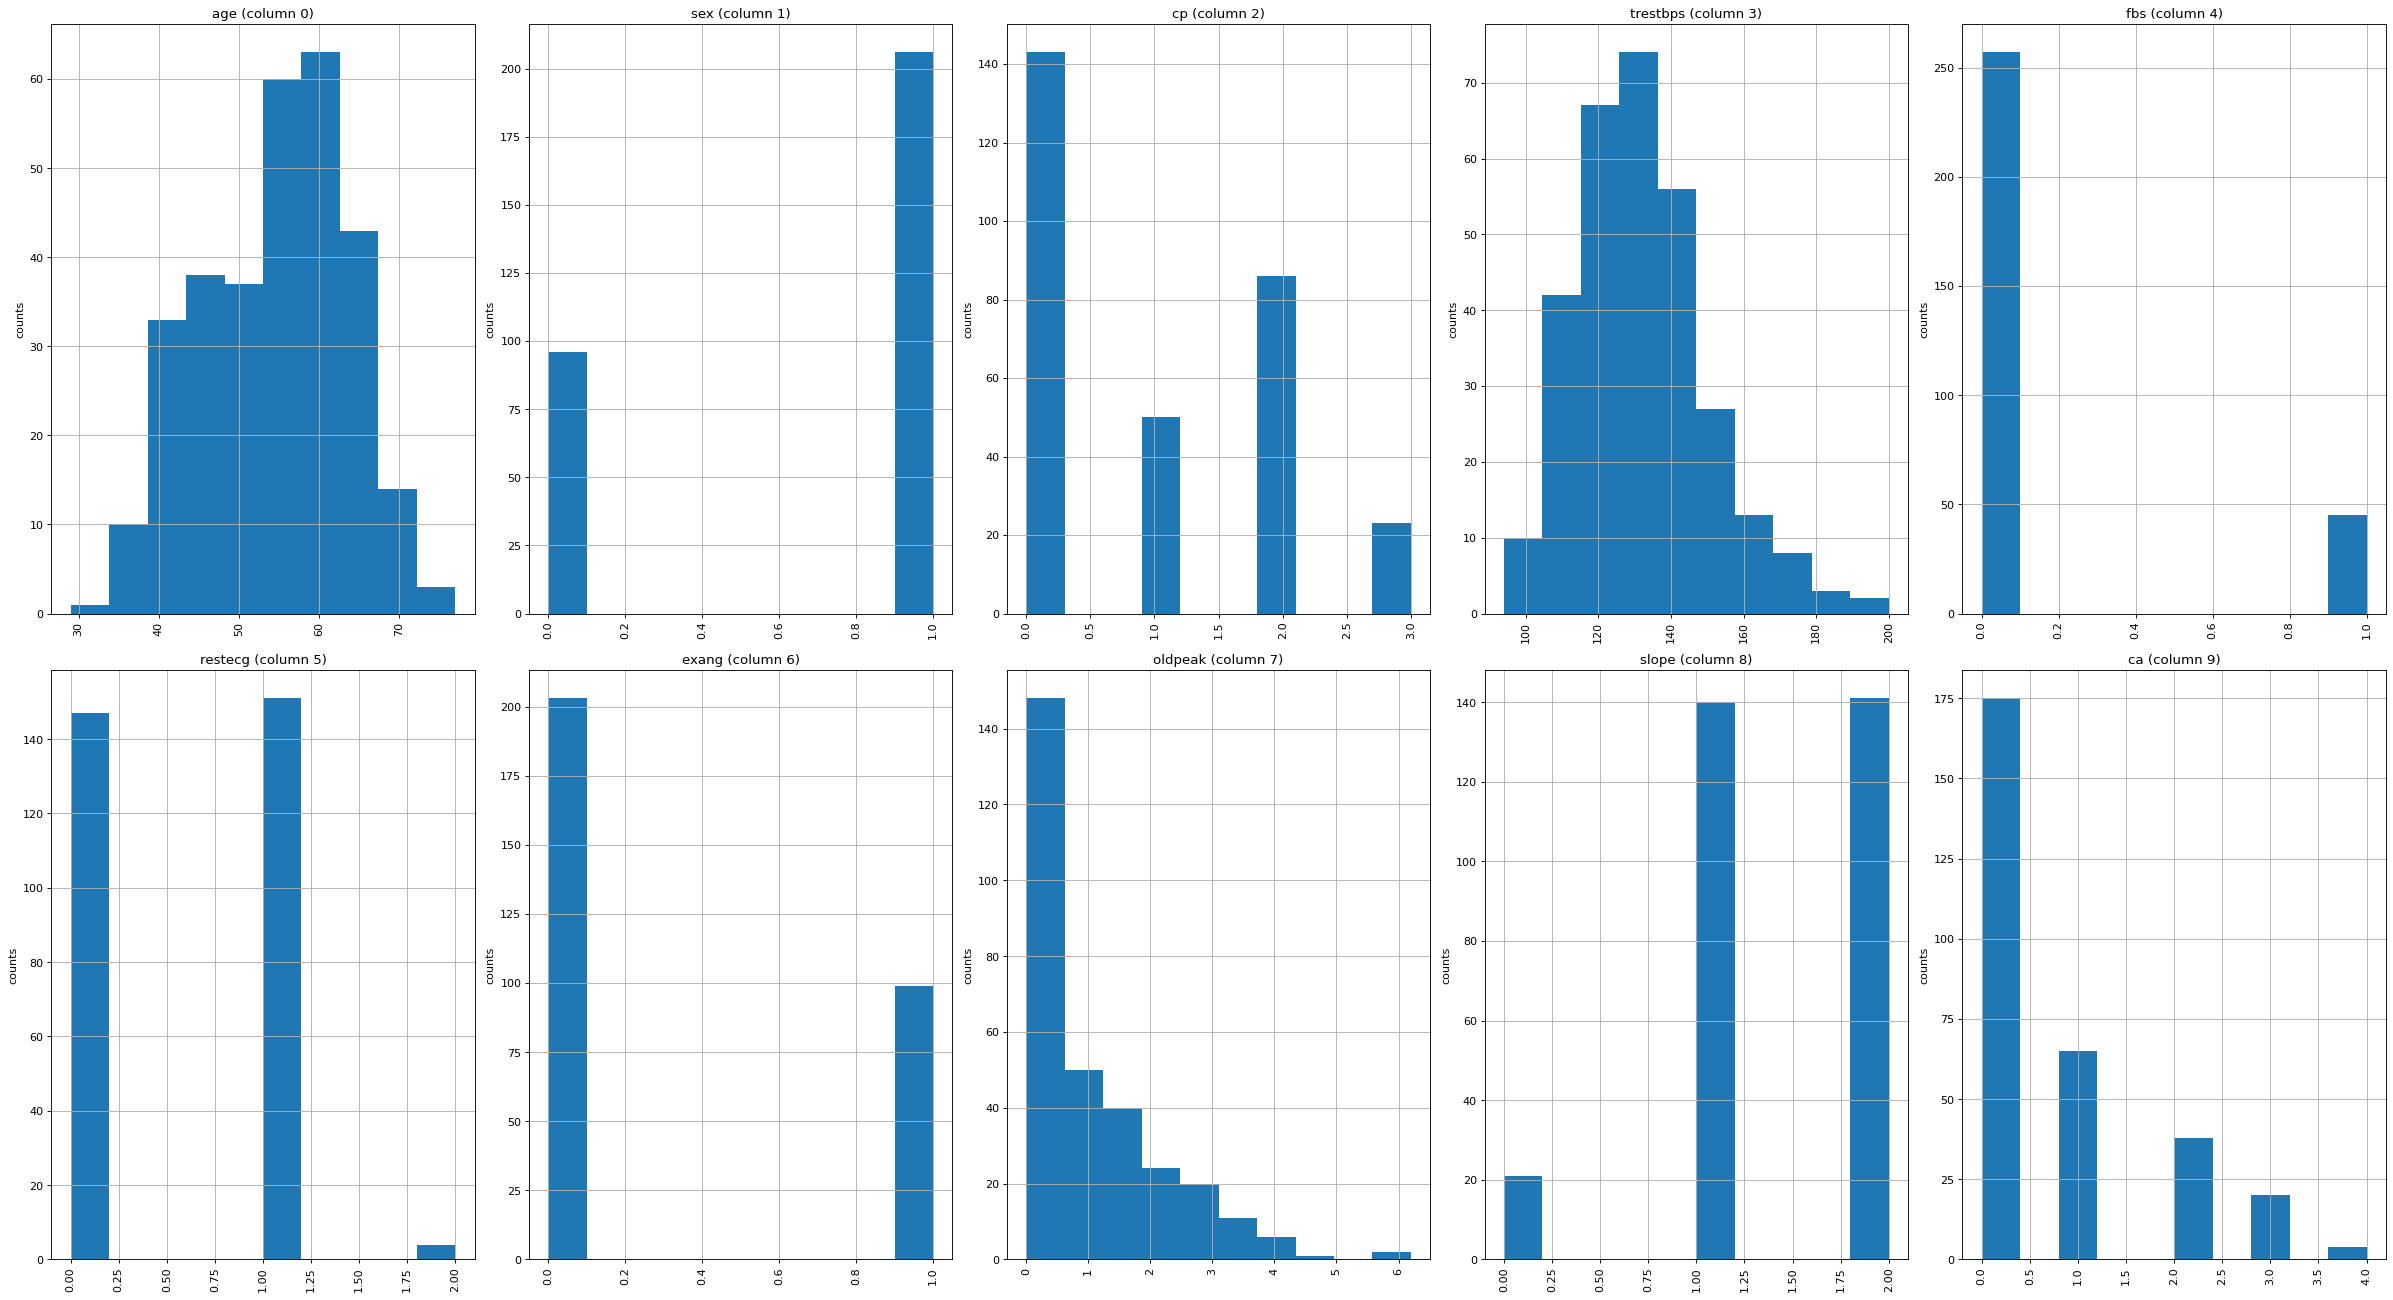

In [58]:
plotPerColumnDistribution(df1, 10, 5)

## Langkah 8: Eksekusi Grafik Matriks Korelasi
Menjalankan matriks korelasi untuk melihat parameter klinis mana yang paling berpengaruh kuat terhadap indikasi penyakit jantung pasien.

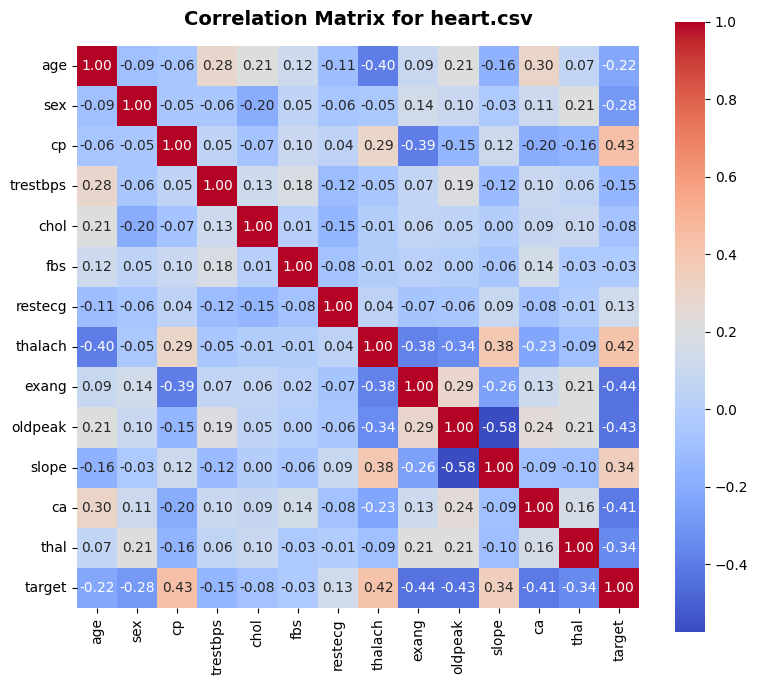

In [59]:
plotCorrelationMatrix(df1, 8)

## Langkah 9: Eksekusi Scatter and Density Plot
Menampilkan representasi sebaran titik data rekam medis secara menyeluruh.

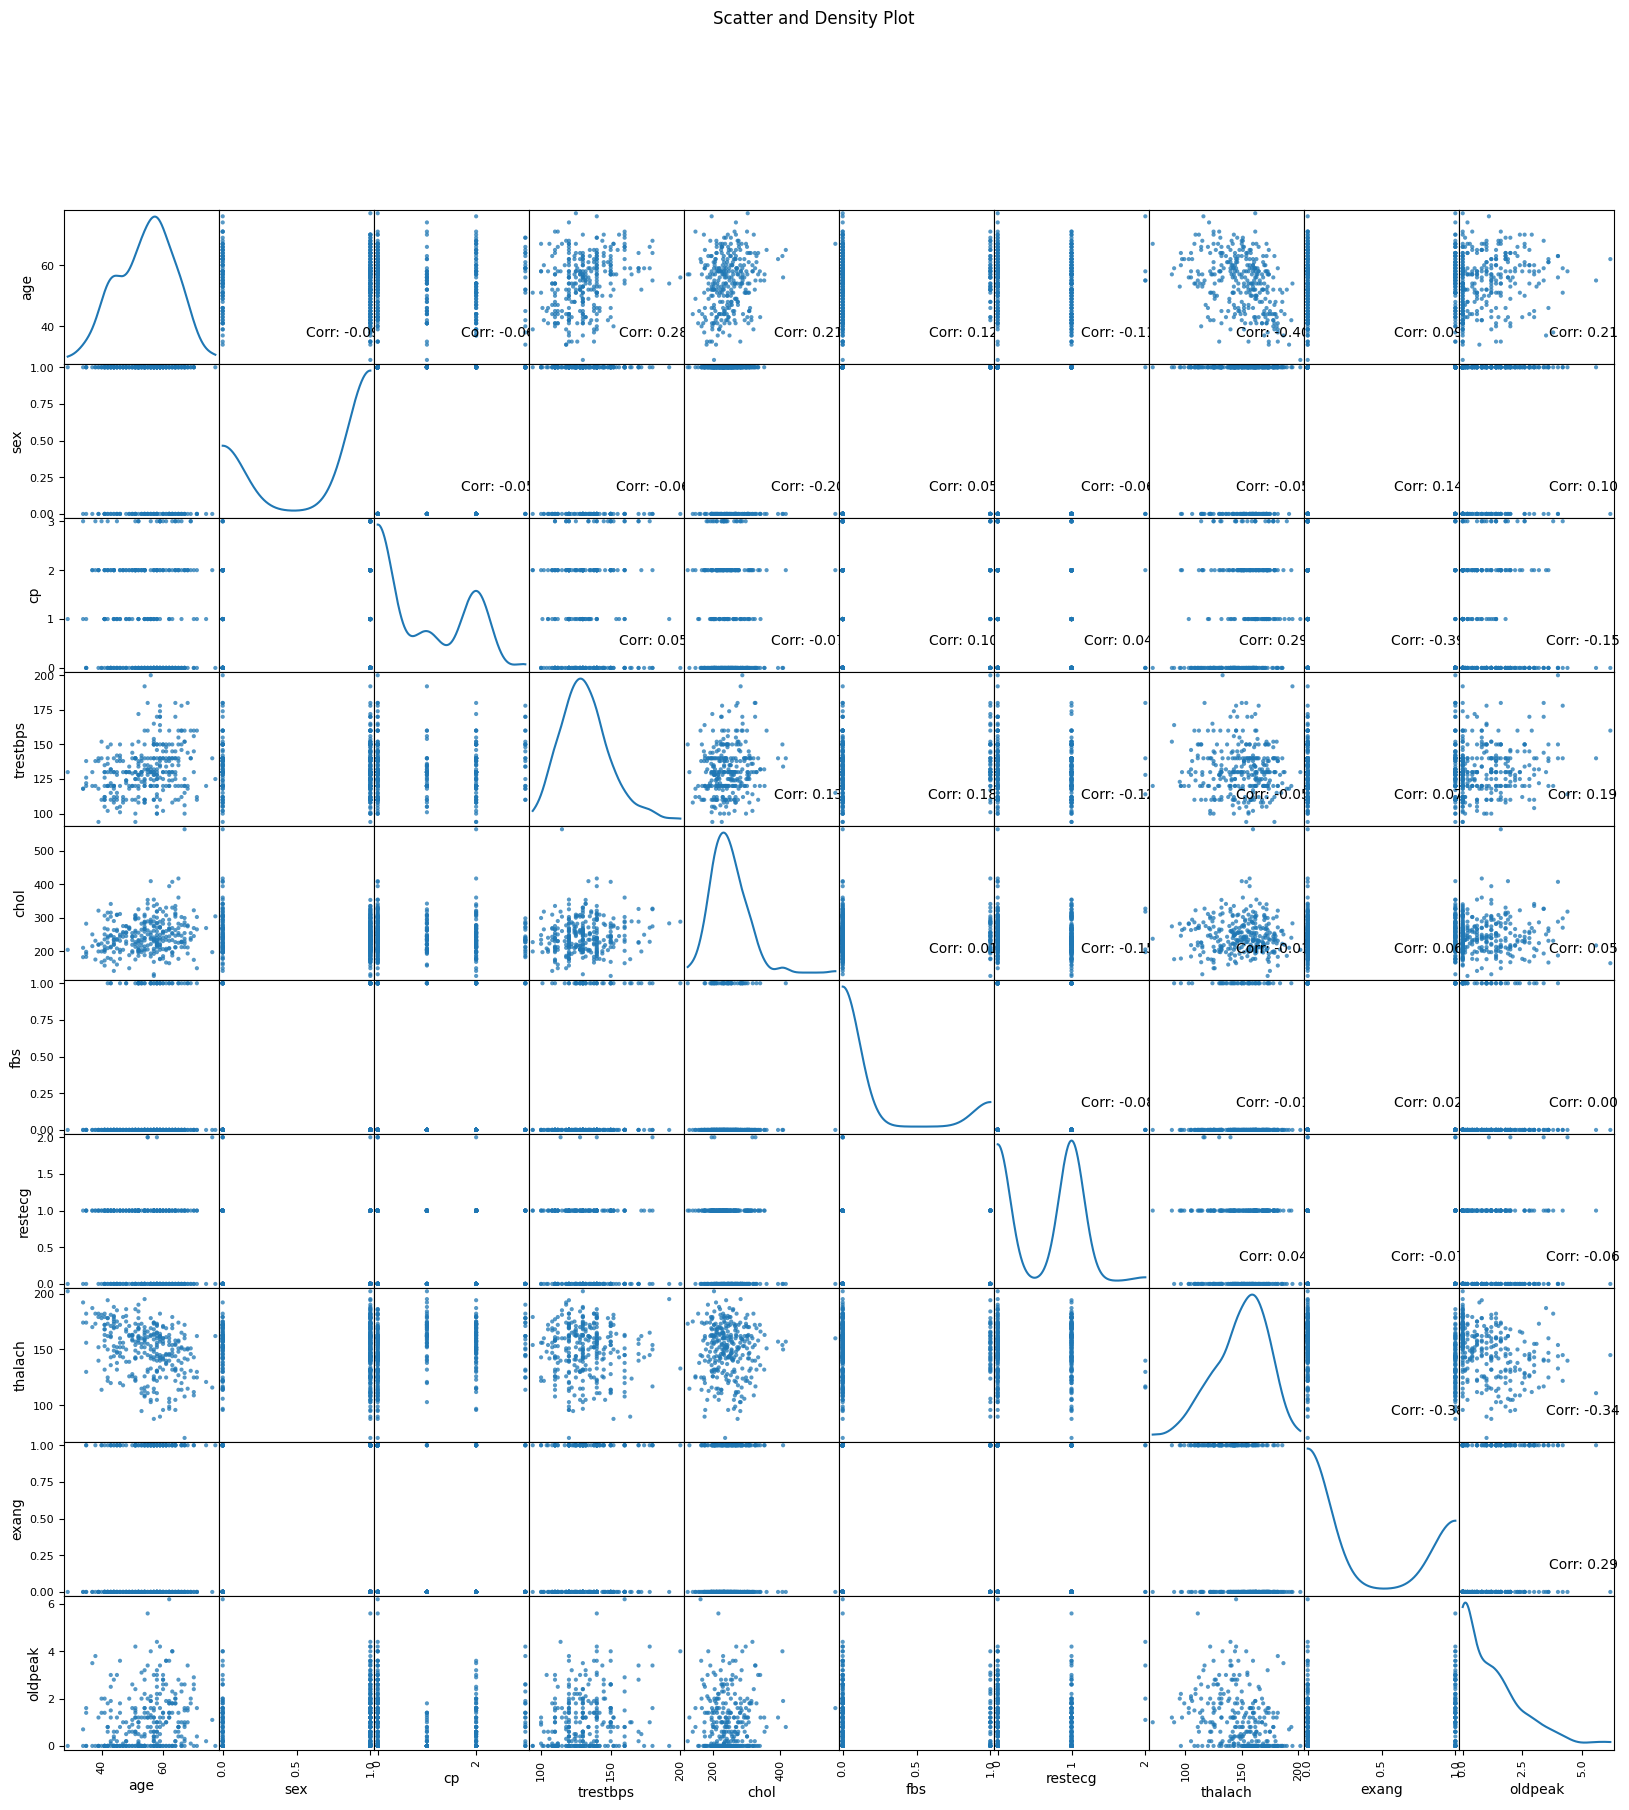

In [60]:
plotScatterMatrix(df1, 20, 10)

# IMPLEMENTASI MACHINE LEARNING (C4.5 & KNN)

## Langkah 10: Memuat Library Pemodelan & Evaluasi Data Mining
Kita mengimpor pustaka khusus dari `sklearn` yang bertanggung jawab untuk membagi dataset, menormalisasi angka, membangun model Decision Tree & KNN, serta menghitung metrik akurasi akurat (*Confusion Matrix*).

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Menggunakan Z-score sesuai paper
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Library Machine Learning berhasil di-import!")

Library Machine Learning berhasil di-import!


## Langkah 11: Pemisahan Fitur Medis dan Label Target (Splitting Data)
Kita memisahkan kolom data menjadi dua bagian: Fitur Medis (`X`) dan Label Target penyakit (`y`). Selanjutnya data dibagi dengan proporsi **80% untuk data latih (training)** dan **20% untuk data uji (testing)**.

In [62]:
# 1. Pemisahan Fitur dan Target
X = df1.drop(columns=['target'])
y = df1['target']

# 2. Splitting Data Rasio 70:30 sesuai teks di Bab METHOD
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Jumlah Data Latih (Training Set 70%): {X_train.shape[0]} sampel")
print(f"Jumlah Data Uji (Testing Set 30%): {X_test.shape[0]} sampel\n")

Jumlah Data Latih (Training Set 70%): 211 sampel
Jumlah Data Uji (Testing Set 30%): 91 sampel



## Langkah 12: Normalisasi Data Rekam Medis (Min-Max Scaling)
Karena KNN berbasis pengukuran jarak (*Euclidean*), variasi rentang angka yang jauh berbeda (misal usia puluhan vs kolesterol ratusan) bisa mengacaukan model. Kita samakan skalanya ke rentang 0-1 menggunakan `MinMaxScaler`.

In [63]:
# 3. Normalisasi menggunakan Z-Score (Standardization) sesuai isi paper
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses normalisasi data latih dan data uji selesai.")

Proses normalisasi data latih dan data uji selesai.


## Langkah 13: Klasifikasi Menggunakan Algoritma Decision Tree C4.5
Kita melatih model pohon keputusan dengan kriteria `entropy` (karakteristik utama algoritma C4.5 untuk menghitung nilai Information Gain) dan menampilkan laporan performa hasil ujinya.

In [64]:
# 4. Implementasi C4.5 dengan Hyperparameter Terkunci (max_depth=8, min_samples_split=5)
c45_model = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_split=5, random_state=42)
c45_model.fit(X_train, y_train)
y_pred_c45 = c45_model.predict(X_test)
acc_c45 = accuracy_score(y_test, y_pred_c45)

print("========= PERFORMA DECISION TREE C4.5 (SESUAI PAPER) =========")
print(f"Akurasi Model: {acc_c45 * 100:.2f}%\n")
print(classification_report(y_test, y_pred_c45))

========= PERFORMA DECISION TREE C4.5 (SESUAI PAPER) =========
Akurasi Model: 72.53%

              precision    recall  f1-score   support

           0       0.67      0.81      0.73        42
           1       0.80      0.65      0.72        49

    accuracy                           0.73        91
   macro avg       0.73      0.73      0.73        91
weighted avg       0.74      0.73      0.72        91



## Langkah 14: Klasifikasi Menggunakan Algoritma K-Nearest Neighbor (KNN)
Kita membangun klasifikasi dengan algoritma KNN menggunakan nilai tetangga terdekat optimal $K=5$ serta metrik jarak biner *Euclidean*, lalu menampilkan rincian hasil evaluasinya.

In [65]:
# 5. Implementasi KNN dengan K=5 dan Jarak Euclidean
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("\n========= PERFORMA K-NEAREST NEIGHBOR (SESUAI PAPER) =========")
print(f"Akurasi Model: {acc_knn * 100:.2f}%\n")
print(classification_report(y_test, y_pred_knn))


========= PERFORMA K-NEAREST NEIGHBOR (SESUAI PAPER) =========
Akurasi Model: 79.12%

              precision    recall  f1-score   support

           0       0.78      0.76      0.77        42
           1       0.80      0.82      0.81        49

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



## Langkah 15: Visualisasi Grafik Batang Perbandingan Akurasi Akhir
Tahap akhir adalah memvisualisasikan perbandingan performa akurasi antara Decision Tree C4.5 dengan KNN ke dalam grafik batang (*Bar Plot*) yang informatif untuk kebutuhan penulisan dokumen laporan.

/tmp/ipykernel_2723/1258576389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


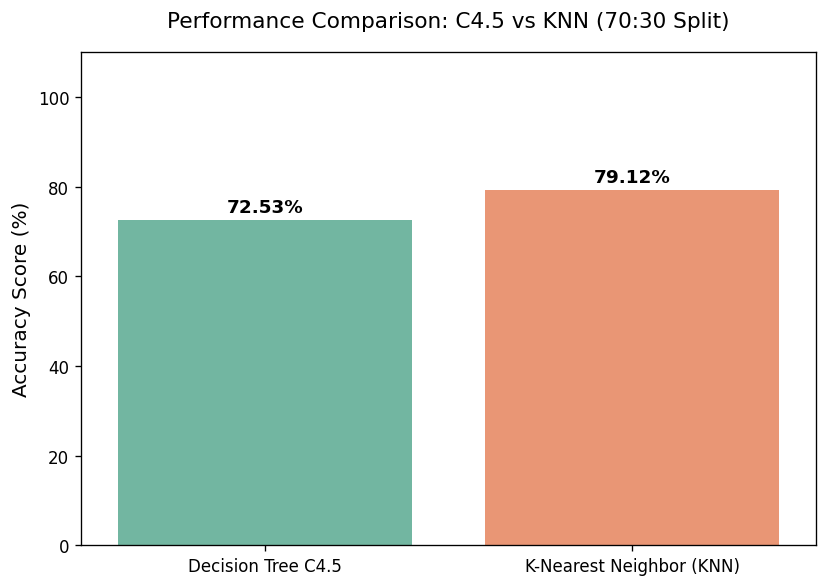

In [66]:
# 6. Pembuatan Grafik Batang untuk Figure 1 di Paper
plt.figure(figsize=(7, 5), dpi=120)
models = ['Decision Tree C4.5', 'K-Nearest Neighbor (KNN)']
accuracies = [acc_c45 * 100, acc_knn * 100]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.ylabel('Accuracy Score (%)', fontsize=12)
plt.title('Performance Comparison: C4.5 vs KNN (70:30 Split)', fontsize=13, pad=15)

for i, val in enumerate(accuracies):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()